In [1]:
!pip install pandas matplotlib openai python-dotenv
!pip install kagglehub[pandas-datasets]


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import re

from openai import OpenAI
import kagglehub
from dotenv import load_dotenv

c:\Users\magdu\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
path = kagglehub.dataset_download(
    "abhinand05/crop-production-in-india"
)

print(path)

C:\Users\magdu\.cache\kagglehub\datasets\abhinand05\crop-production-in-india\versions\1


In [4]:
for root, dirs, files in os.walk(path):
    for file in files:
        print(file)

crop_production.csv


In [5]:
csv_file = os.path.join(path, "crop_production.csv")

df = pd.read_csv(csv_file)

df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [6]:
summary = f"""
Rows: {len(df)}
Columns: {list(df.columns)}

Missing Values:
{df.isnull().sum()}
"""

print(summary)


Rows: 246091
Columns: ['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production']

Missing Values:
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64



In [7]:
df["Production"].isnull().sum()

3730

In [8]:
df[df["Production"].isnull()].head(20)

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
46,Andaman and Nicobar Islands,NICOBARS,2005,Whole Year,Arecanut,795.67,NaN
51,Andaman and Nicobar Islands,NICOBARS,2005,Whole Year,Dry chillies,17.00,NaN
623,Andhra Pradesh,ANANTAPUR,2007,Kharif,Moong(Green Gram),1000.00,NaN
630,Andhra Pradesh,ANANTAPUR,2007,Rabi,Horse-gram,1000.00,NaN
698,Andhra Pradesh,ANANTAPUR,2009,Rabi,Rapeseed &Mustard,8.00,NaN
723,Andhra Pradesh,ANANTAPUR,2010,Kharif,Other Kharif pulses,1.00,NaN
1153,Andhra Pradesh,CHITTOOR,2001,Rabi,Wheat,4.00,NaN
1317,Andhra Pradesh,CHITTOOR,2004,Rabi,Wheat,2.00,NaN
1419,Andhra Pradesh,CHITTOOR,2007,Kharif,Moong(Green Gram),1000.00,NaN
1423,Andhra Pradesh,CHITTOOR,2007,Kharif,Small millets,1000.00,NaN


In [9]:
df = df.dropna(subset=["Production"])

print(df.shape)
print(df["Production"].isnull().sum())

(242361, 7)
0


In [10]:
string_cols = [
    "State_Name",
    "District_Name",
    "Season",
    "Crop"
]

for col in string_cols:
    df[col] = df[col].str.strip()

In [11]:
print("States:", df["State_Name"].nunique())
print("Districts:", df["District_Name"].nunique())
print("Crops:", df["Crop"].nunique())

States: 33
Districts: 646
Crops: 124


In [12]:
metadata = {
    "State_Name": {
        "type": "categorical",
        "unique_values": df["State_Name"].nunique()
    },
    "District_Name": {
        "type": "categorical",
        "unique_values": df["District_Name"].nunique()
    },
    "Crop_Year": {
        "type": "numeric",
        "min": int(df["Crop_Year"].min()),
        "max": int(df["Crop_Year"].max())
    },
    "Season": {
        "type": "categorical",
        "values": list(df["Season"].unique())
    },
    "Crop": {
        "type": "categorical",
        "unique_values": df["Crop"].nunique()
    },
    "Area": {
        "type": "numeric"
    },
    "Production": {
        "type": "numeric"
    }
}

In [13]:
with open("schema.json", "w") as f:
    json.dump(metadata, f, indent=4)

In [14]:
VALID_STATES = sorted(
    df["State_Name"].unique().tolist()
)

VALID_CROPS = sorted(
    df["Crop"].unique().tolist()
)

In [15]:
def execute_query(df, crop, year):

    result = (
        df[
            (df["Crop"] == crop) &
            (df["Crop_Year"] == year)
        ]
        .groupby("State_Name")["Production"]
        .sum()
        .sort_values(ascending=False)
    )

    return result

In [16]:
execute_query(df, "Rice", 2014).head(10)

State_Name
Andhra Pradesh    16911168.0
West Bengal       15927196.0
Uttar Pradesh     13316967.0
Punjab            11107000.0
Odisha             9840000.0
Bihar              8241624.0
Chhattisgarh       7977746.0
Assam              5222645.0
Telangana          4544982.0
Karnataka          4027747.0
Name: Production, dtype: float64

In [17]:
def production_trend(df, crop, state):

    trend = (
        df[
            (df["Crop"] == crop) &
            (df["State_Name"] == state)
        ]
        .groupby("Crop_Year")["Production"]
        .sum()
        .reset_index()
    )

    return trend

In [18]:
trend = production_trend(
    df,
    "Rice",
    "Punjab"
)

trend.head()

,Crop_Year,Production
0,1997,7904000.0
1,1998,7940000.0
2,1999,8716000.0
3,2000,9154000.0
4,2001,8816000.0


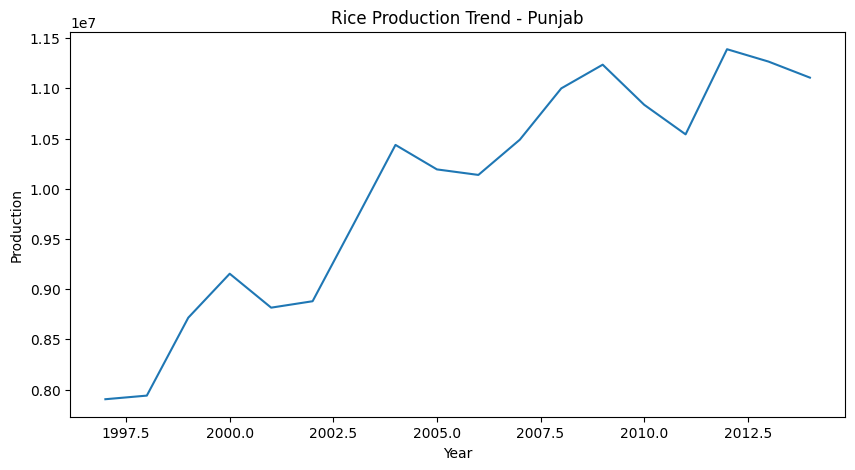

In [19]:
plt.figure(figsize=(10,5))

plt.plot(
    trend["Crop_Year"],
    trend["Production"]
)

plt.title("Rice Production Trend - Punjab")
plt.xlabel("Year")
plt.ylabel("Production")

plt.show()

In [20]:
load_dotenv()

client = OpenAI(
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1"
)

In [21]:
dataset_context = """
Dataset Columns:

State_Name
District_Name
Crop_Year
Season
Crop
Area
Production

Valid Operations:

max
trend

Return ONLY JSON.
"""

In [22]:
def parse_query(question):

    prompt = f"""
{dataset_context}

Available States:
{VALID_STATES}

Available Crops:
{VALID_CROPS}

Question:
Which state produced the most rice in 2014?

Output:
{{
  "operation":"max",
  "crop":"Rice",
  "year":2014
}}

Question:
Which state produced the least rice in 2014?

Output:
{{
  "operation":"min",
  "crop":"Rice",
  "year":2014
}}

Question:
What was the total rice production in 2014?

Output:
{{
  "operation":"sum",
  "crop":"Rice",
  "year":2014
}}

Question:
What was the average rice production in 2014?

Output:
{{
  "operation":"avg",
  "crop":"Rice",
  "year":2014
}}

Question:
Top 10 states by rice production in 2014

Output:
{{
  "operation":"top_n",
  "crop":"Rice",
  "year":2014,
  "n":10
}}

Question:
Show rice production trend in Punjab

Output:
{{
  "operation":"trend",
  "crop":"Rice",
  "state":"Punjab"
}}

Question:
{question}

Return ONLY JSON.
"""

    response = client.chat.completions.create(
        model="google/gemma-4-31b-it:free",
        messages=[
            {
                "role":"user",
                "content":prompt
            }
        ],
        temperature=0
    )

    content = response.choices[0].message.content

    print("RAW RESPONSE:")
    print(content)

    content = re.sub(r"^```json\s*", "", content.strip())
    content = re.sub(r"^```\s*", "", content)
    content = re.sub(r"\s*```$", "", content)

    match = re.search(r"\{.*\}", content, re.DOTALL)

    if not match:
        raise ValueError("No JSON found")

    return json.loads(match.group(0))

In [23]:
def validate_query(query, df):

    if "crop" in query:

        if query["crop"] not in df["Crop"].unique():

            return False, "Crop not found"

    if "state" in query:

        if query["state"] not in df["State_Name"].unique():

            return False, "State not found"

    return True, ""

In [24]:
def run_query(df, query):

    crop = query.get("crop")
    year = query.get("year")

    if query["operation"] in ["max", "min", "top_n"]:

        result = (
            df[
                (df["Crop"] == crop) &
                (df["Crop_Year"] == year)
            ]
            .groupby("State_Name")["Production"]
            .sum()
            .sort_values(ascending=False)
        )

    if query["operation"] == "max":

        return {
            "state": result.index[0],
            "production": float(result.iloc[0])
        }

    elif query["operation"] == "min":

        result = result.sort_values()

        return {
            "state": result.index[0],
            "production": float(result.iloc[0])
        }

    elif query["operation"] == "sum":

        total = (
            df[
                (df["Crop"] == crop) &
                (df["Crop_Year"] == year)
            ]["Production"]
            .sum()
        )

        return {
            "total_production": float(total)
        }

    elif query["operation"] == "avg":

        avg = (
            df[
                (df["Crop"] == crop) &
                (df["Crop_Year"] == year)
            ]["Production"]
            .mean()
        )

        return {
            "average_production": float(avg)
        }

    elif query["operation"] == "top_n":

        n = query.get("n", 10)

        return result.head(n)

    elif query["operation"] == "trend":

        return (
            df[
                (df["Crop"] == crop) &
                (df["State_Name"] == query["state"])
            ]
            .groupby("Crop_Year")["Production"]
            .sum()
            .reset_index()
        )

    return "Unsupported Query"

In [25]:
def generate_explanation(question, query, result):

    operation = query["operation"]

    if operation == "max":

        return f"""
Question:
{question}

Answer:
{result['state']} produced the highest amount of {query['crop']} in {query['year']}.

Production:
{result['production']:,.0f}
"""

    elif operation == "min":

        return f"""
Question:
{question}

Answer:
{result['state']} produced the lowest amount of {query['crop']} in {query['year']}.

Production:
{result['production']:,.0f}
"""

    elif operation == "sum":

        return f"""
Question:
{question}

Total {query['crop']} Production in {query['year']}:

{result['total_production']:,.0f}
"""

    elif operation == "avg":

        return f"""
Question:
{question}

Average {query['crop']} Production in {query['year']}:

{result['average_production']:,.2f}
"""

    elif operation == "top_n":

        return f"""
Question:
{question}

Showing top producing states.
"""

    elif operation == "trend":

        return f"""
Question:
{question}

Trend generated successfully.
"""

    return str(result)

In [26]:
query = parse_query(
    "Which state produced the most rice in 2014?"
)

print(query)

RAW RESPONSE:
```json
{
  "operation": "max",
  "crop": "Rice",
  "year": 2014
}
```
{'operation': 'max', 'crop': 'Rice', 'year': 2014}


In [27]:
valid, msg = validate_query(query, df)

if not valid:
    print(msg)

else:
    result = run_query(df, query)

    print(result)

{'state': 'Andhra Pradesh', 'production': 16911168.0}


In [28]:
question = "Which state produced the most rice in 2014?"

query = parse_query(question)

valid, msg = validate_query(query, df)

if not valid:
    print(msg)

else:
    result = run_query(df, query)

    print(result)

    print(
        generate_explanation(
            question,
            query,
            result
        )
    )

RAW RESPONSE:
```json
{
  "operation": "max",
  "crop": "Rice",
  "year": 2014
}
```
{'state': 'Andhra Pradesh', 'production': 16911168.0}

Question:
Which state produced the most rice in 2014?

Answer:
Andhra Pradesh produced the highest amount of Rice in 2014.

Production:
16,911,168



RAW RESPONSE:
```json
{
  "operation": "trend",
  "crop": "Rice",
  "state": "Punjab"
}
```


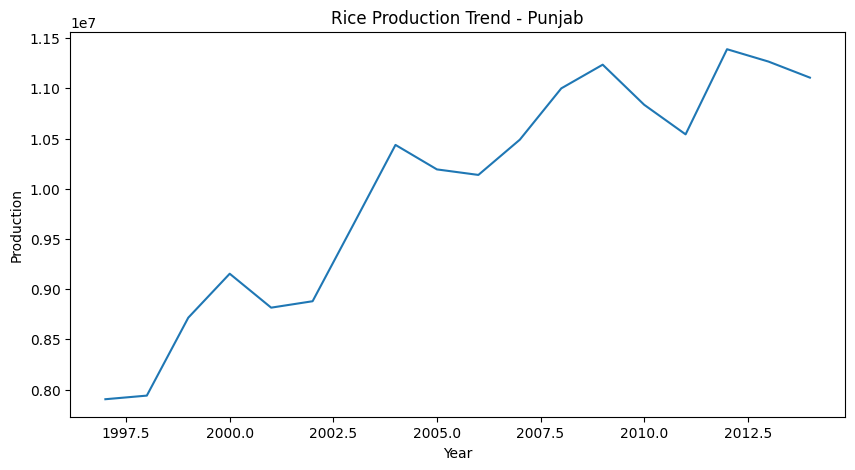


Question:
Show rice production trend in Punjab

Trend generated successfully.



In [29]:
question = "Show rice production trend in Punjab"

query = parse_query(question)

valid, msg = validate_query(query, df)

if not valid:
    print(msg)

else:

    result = run_query(df, query)

    plt.figure(figsize=(10,5))

    plt.plot(
        result["Crop_Year"],
        result["Production"]
    )

    plt.title(
        f"{query['crop']} Production Trend - {query['state']}"
    )

    plt.xlabel("Year")
    plt.ylabel("Production")

    plt.show()

    print(
        generate_explanation(
            question,
            query,
            result
        )
    )

In [31]:
question = input("Ask a question: ")

query = parse_query(question)

valid, msg = validate_query(query, df)

if not valid:

    print(msg)

else:

    result = run_query(df, query)

    if query["operation"] == "trend":

        plt.figure(figsize=(10,5))

        plt.plot(
            result["Crop_Year"],
            result["Production"]
        )

        plt.title(
            f"{query['crop']} Production Trend - {query['state']}"
        )

        plt.xlabel("Year")
        plt.ylabel("Production")

        plt.show()

    else:

        print(result)

    print(
        generate_explanation(
            question,
            query,
            result
        )
    )

RAW RESPONSE:
```json
{
  "operation": "top_n",
  "crop": "Rice",
  "year": 2014,
  "n": 3
}
```
State_Name
Andhra Pradesh    16911168.0
West Bengal       15927196.0
Uttar Pradesh     13316967.0
Name: Production, dtype: float64

Question:
Top 3 states by rice production in 2014

Showing top producing states.

